<a href="https://colab.research.google.com/github/voronv27/projects-in-ai-and-ml/blob/main/HW4/Homework4_task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 3

##Part 1: Implementing Word Embeddings

I decided to use BERT. BERT is the most heavily computational model of the listed options on the homework assignment (Word2Vec, GloVe, FastText, or BERT embeddings), but it has benefits over lighter models like Word2Vec.

For one, BERT better handles multiple meanings for the same word by looking at the context (contextual vs static embeddings). For example, "pitcher" can be a baseball pitcher or a pitcher of lemonade, and "bank" can correspond to a bank account or the bank of a river, but the other models will map both to the same embedding. Ignoring context and providing the same, static embedding means poorer performance. In our problem, we will be taking two words as input. So a user could type "river bank" or "bank account" and BERT would provide different embeddings for the two different "banks", which should have better results.

BERT also handles unseen/OOV words by splitting them into smaller subwords and analyzing the subwords, as well as looking at the words surrounding the unknown word to get context for what it could mean. Word2Vec and GloVe don't have any OOV handling, though FastText does. For this assignment, where we need to handle OOV cases, choosing a model with that logic already built-in makes sense.

We will load the embeddings using Hugging Face. Once the code below is run, our model will be ready to create embeddings.

In [1]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

model.eval()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

Here is the code to allow dynamic user input of two words, then output their respective embeddings:

In [2]:
def get_embeddings(words, print_embeddings=True):
  inputs = tokenizer(words, return_tensors="pt")
  inputs = {k: v.to(device) for k, v in inputs.items()}
  with torch.no_grad():
    outputs = model(**inputs)

  embeddings = outputs.last_hidden_state

  if not print_embeddings:
    return embeddings # return early

  # print embeddings per token, skipping CLS and SEP since we only care about the 2 words
  # for words that get broken down into subwords, merge them back to one word
  tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
  curr_word = ""
  curr_embedding = []
  for token, embedding in zip(tokens[1:-1], embeddings[0][1:-1]):
    if token.startswith("##"):
      curr_word += token[2:]
      curr_embedding.append(embedding)
    else:
      if curr_word != "":
        word_embedding = torch.stack(curr_embedding).mean(dim=0)
        print(f"{curr_word} ({len(curr_embedding)} subwords) embedding:\n {word_embedding}\n")
      curr_word = token
      curr_embedding = [embedding]

  if curr_word != "":
    word_embedding = torch.stack(curr_embedding).mean(dim=0)
    print(f"{curr_word} ({len(curr_embedding)} subwords) embedding:\n {word_embedding}\n")

  return embeddings

def input_to_embedding():
  words = None
  while words is None:
    words = input("Enter two words: ")
    if words and len(words.split()) != 2:
      print("Please enter two words separated by a space")
      words = None
  get_embeddings(words)

input_to_embedding()

Enter two words: hello world
hello (1 subwords) embedding:
 tensor([-3.6327e-01,  1.4122e-01,  8.7999e-01, -1.0147e+00, -1.1978e-01,
        -1.1537e-01,  4.7872e-01,  5.8287e-01, -4.4683e-01, -1.1548e+00,
        -3.9242e-01, -5.3255e-01,  2.6286e-02,  2.0164e-01,  7.5776e-02,
         4.2767e-01, -5.3023e-01,  5.0495e-01,  3.4939e-01,  1.1076e+00,
        -6.7725e-01, -2.4087e-01,  5.4712e-02,  2.2762e-01,  8.3598e-02,
        -4.9641e-01, -1.3317e-01,  5.0224e-01, -5.1253e-01, -6.5701e-01,
        -1.2540e-01, -6.2709e-01,  2.7334e-02,  8.7963e-02, -1.0595e+00,
        -4.6341e-01, -4.1921e-01,  5.6955e-01, -8.1138e-01,  1.0153e-01,
         1.5255e-01, -4.3484e-01,  8.0157e-01, -2.1419e-01, -8.7144e-02,
        -8.7274e-01, -5.1256e-01, -1.8799e-01, -3.4243e-01, -8.7103e-01,
        -6.5427e-02,  7.4628e-02, -5.8162e-01,  5.4276e-01,  6.0718e-01,
         8.1182e-01, -1.2827e-01, -3.6570e-01,  3.1617e-01,  7.3031e-02,
        -4.4888e-01,  1.8916e-01,  1.2621e+00, -1.8829e-01, -9.0

BERT handles OOV words by breaking them into subwords and looking at context. Here is an example of me inputting an OOV word not in BERT:

In [3]:
input_to_embedding()

Enter two words: icecream sandwich
icecream (3 subwords) embedding:
 tensor([-2.2382e-01,  3.4818e-01, -1.2229e-02,  8.7646e-02,  8.7206e-01,
        -1.3611e-01,  2.4280e-01,  8.7914e-01, -6.1512e-01, -4.4165e-01,
        -5.3469e-03, -1.1135e+00, -3.1962e-01,  4.9503e-01, -4.1213e-01,
         1.7353e-01, -4.8374e-02,  6.4233e-01,  6.3257e-01,  3.2028e-01,
         3.0036e-01, -4.2729e-01, -7.5626e-01,  6.5160e-01,  5.7559e-01,
        -6.4286e-01,  1.1480e-01,  4.4191e-01,  3.9197e-01, -9.9978e-02,
         5.5453e-02,  2.5578e-01,  1.5668e-01, -2.9251e-01,  1.3148e-02,
         7.6647e-02, -5.6529e-01,  4.1035e-01, -2.9724e-01,  2.1380e-01,
        -3.7349e-01, -4.4796e-01,  3.9449e-02,  1.6266e-01,  1.9828e-01,
        -7.1679e-03,  1.3473e-01, -2.4762e-01, -2.0986e-01, -1.9976e-01,
        -3.3884e-01,  4.1381e-01, -7.2219e-01, -2.3377e-01, -7.9751e-02,
         7.3225e-01,  3.7207e-03, -8.9362e-01, -8.0147e-02, -5.5688e-02,
         1.8477e-01, -9.6353e-03,  1.7136e-01, -1.6225e

As seen above, it splits "icecream" into 3 subwords, meaning "icecream" itself was not in its known words. However, it still produced an embedding for "icecream" by breaking it into subwords. We can see exactly which subwords it broke it into:

In [4]:
words = "icecream"
inputs = tokenizer(words, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
for token in tokens[1:-1]:
  print("subword:", token)

subword: ice
subword: ##cre
subword: ##am


The subword "ice" should help the embedding for "icecream" be similar to "cold" words (words that mean cold or are cold objects, etc). In addition, in the context of a full sentence like "I am eating icecream", BERT would be able to get the context that "icecream" is something to be eaten, which should also help provide a more accurate embedding. Models like Word2Vec would only state that icecream is OOV and provide no embedding, which is less helpful.

##Part 2: Cosine Similarity Computation

Now, let us implement a function to compute the cosine similarity between two-word embeddings.

(Note: as two-word was hyphenated in the homework document, I took it to mean comparing two words to another two words. If this was the incorrect interpretation, the cosine_similarity function can be used to compare a single word to another word instead, and in fact, in part 3 we use it with single words).

In [5]:
def cosine_similarity(words1, words2):
  # get embeddings for our word pairs
  embeddings1 = get_embeddings(words1, False)
  embeddings2 = get_embeddings(words2, False)

  # compare with cosine similarity
  # (A . B) / (||A|| x ||B||)
  embeddings1 = embeddings1[0][1:-1].mean(dim=0)
  embeddings2 = embeddings2[0][1:-1].mean(dim=0)
  sim = torch.dot(embeddings1, embeddings2)
  sim /= torch.norm(embeddings1)
  sim /= torch.norm(embeddings2)
  return sim.item()

In [6]:
# example cosine similarities
print(cosine_similarity("rubber duck", "bath toy"))
print(cosine_similarity("flute music", "piano melody"))
print(cosine_similarity("exciting fun", "tired melancholy"))

0.6840271949768066
0.7027717232704163
0.5131140947341919


###Why is Cosine Similarity Useful?

Cosine similarity is useful in word embedding space because the value is based on the "angle" between the two vectors, rather than metrics like Euclidean distance, which takes magnitude into account.

Firstly, cosine similarity bounds the result between -1 and 1, which is helpful since it's scaled.

In addition, for a lot of dimensions (and there are a lot in a word embedding), the Euclidean distance between two points will tend to increase, while focusing on the angle between them is more stable.

Finally, magnitudes in word embeddings can represent things like strength and frequency, and that means the magnitudes don't necessarily correlate to how similar two words are in meaning. If we compare by magnitude, "halt" and "stop" will have differing magnitudes due to how frequently they are used/their uniqueness, which could lead to a larger distance between them than is actually representative of their similarity. On the other hand, the angle between these two word embeddings should be fairly small since they convey a similar meaning, meaning cosine similarity is more likely to correctly find these words to be similar.

###Batch Processing

Now we will write a function to take multiple word pairs from the user and compute the similarities between all of them.

(Note: I was a unsure on whether "word pairs" corresponded to two words compared to another two words, or one word compared to another. I interpreted the wording of the problem  to mean inputting multiple two-word pairs to compare against other pairs. If that is incorrect, the code below can be modified to only take one word each iteration of the input loop.)

In [8]:
def batch_cosine_similarity():
  # get user-inputted pairs
  words = []
  while True:
    pair = input("Enter word pair (type 'stop' to stop): ")
    if pair == "stop":
      break
    if pair and len(pair.split()) != 2:
      print("Please enter two words separated by a space or 'stop' to stop")
    else:
      words.append(pair)

  # compute similarities
  similarities = dict()
  for pair in words:
    print()
    similarities[pair] = dict()
    for pair2 in words:
      if pair2 == pair:
        continue
      similarities[pair][pair2] = cosine_similarity(pair, pair2)

      # avoid double printing
      if not pair2 in similarities:
        print(f"{pair} and {pair2} similarity: {similarities[pair][pair2]: .4f}")

  return similarities

_ = batch_cosine_similarity()

Enter word pair (type 'stop' to stop): hello world
Enter word pair (type 'stop' to stop): happy sad
Enter word pair (type 'stop' to stop): butterfly music
Enter word pair (type 'stop' to stop): last pair
Enter word pair (type 'stop' to stop): stop

hello world and happy sad similarity:  0.5333
hello world and butterfly music similarity:  0.4331
hello world and last pair similarity:  0.4034

happy sad and butterfly music similarity:  0.4613
happy sad and last pair similarity:  0.3348

butterfly music and last pair similarity:  0.4202



###Visualization

Here is a scatter plot with some words to show how they cluster together in the embedding space:

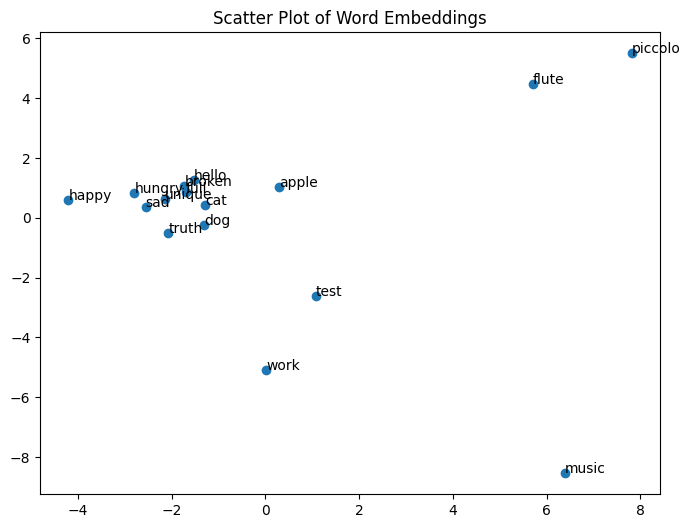

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

words = [
    "hello",
    "happy",
    "sad",
    "truth",
    "unique",
    "music",
    "flute",
    "piccolo",
    "apple",
    "hungry",
    "full",
    "test",
    "work",
    "broken",
    "dog",
    "cat"
]

embeddings = [get_embeddings(w, False) for w in words]
embeddings = np.stack([e[0][1:-1].mean(dim=0).cpu().numpy() for e in embeddings])

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.title("Scatter Plot of Word Embeddings")
for i, word in enumerate(words):
  x,y = embeddings_2d[i]
  plt.annotate(word, (x,y))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])

It seems that the more "unique" words tend to be more scattered compared to the more common words. Flute and piccolo, despite both being woodwind instruments, have more distance than dog and cat, though I'd personally argue that they're more similar than dog and cat. Still, they're probably further apart due to the difference in how common/frequently used they are. It surprised me that flute and music were so far apart--though I suppose you can't actually substitute one for another in a sentence, a flute is a musical instrument.

There ended up being one cluster on the graph, which contained most of the more "common" words. Sad and hungry were fairly close, which I find entertaining. I was expecting happy and sad to be further apart due to opposing meanings, but them being close together makes sense since they are both commonly used and both emotions, which actually makes them similar.

##Part 3: Designing a Novel Dissimilarity Metric

###Similarity/Dissimilarity Metrics Function

In [10]:
!pip install nltk --quiet
import nltk
from nltk.corpus import wordnet as wn

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [11]:
def embedding_similarity(word1, word2, metric="cosine"):
  # computes similarity/dissimilarity between two words via chosen metric
  if metric == "cosine":
    return cosine_similarity(word1, word2)

  embeddings1 = get_embeddings(word1, False)
  embeddings2 = get_embeddings(word2, False)

  if metric == "euclidean":
    # how far apart words are in vector space
    # sqrt( (x1-x2)^2 )
    return torch.norm(embeddings1 - embeddings2).item()
  elif metric == "manhattan":
    # how far apart words are via grid-like paths
    # sum_(i=1 to n dimensions) | x1i - x2i |
    return torch.sum(torch.abs(embeddings1 - embeddings2)).item()
  elif metric == "semantic_contrast":
    # get all synsets
    syn1 = wn.synsets(word1)
    syn2 = wn.synsets(word2)
    if not syn1 or not syn2:
      return "word not in wordnet"

    # get max similarity between all synsets
    # s1.path_similarity(s2) returns up to 1
    max_sim = max(
        [s1.path_similarity(s2) for s1 in syn1 for s2 in syn2]
    )

    # do 1-similarity to get contrast
    return 1 - max_sim
  elif metric == "cosine_similarity_distance":
    # cosine similarity that also considers distance
    cos_sim = cosine_similarity(word1, word2)
    euclid_dist = torch.norm(embeddings1 - embeddings2).item()

    # use exponential scaling on distance to scale from 0 to 1
    # as distance increases, this goes to 0
    scaled_euclid_dist = torch.exp(torch.tensor(-0.1 * euclid_dist)).item()

    # distance adds a "penalty" to be subtracted from similarity
    # the larger distance is, the more cos_sim is penalized
    # I chose a max 0.2 penalty to keep it from being too high
    return cos_sim - 0.2*(1-scaled_euclid_dist)
  else:
    return "invalid metric"


I first implemented some existing metrics, referencing the following articles for [Euclidean Distance](https://www.geeksforgeeks.org/maths/euclidean-distance/) and [Manhattan Distance](https://www.geeksforgeeks.org/data-science/manhattan-distance/).

While my semantic contrast measure is technically "my own", I mainly make use of wordnet's path_similarity function. The only difference is that to compare contrast rather than similarity, I return 1 - similarity. I read about path as a similarity measure in [WordNet::Similarity - Measuring the Relatedness of Concepts](https://www.d.umn.edu/~tpederse/Pubs/AAAI04PedersenT.pdf) and referenced the [WordNet documentation](https://www.nltk.org/howto/wordnet.html) to properly use path_similarity.

Finally, I implemented a more truly "custom" metric which combines cosine similarity with Euclidean Distance, by penalizing the cosine similarity based on the scaled Euclidean Distance between the values. If the distance is greater, the cosine similarity will be decreased. Just as comparing by only distance is flawed because magnitudes don't fully correspond to the similarity between words (as I discussed in part 2), comparing by only angle doesn't take into consideration the strength of the word being used as well. I believe that a better metric looks at both distance and angle to decide similarity.

Comparing a few words via different metrics:

In [12]:
import random
random.seed(42)

words_subset = random.sample(words, 5)
metrics = ["cosine", "euclidean", "manhattan", "semantic_contrast", "cosine_similarity_distance"]
for metric in metrics:
  print(metric.upper())
  for word1 in words_subset:
    for word2 in words_subset:
      if word1 == word2:
        continue
      sim = embedding_similarity(word1, word2, metric)
      metric_type = "dissimilarity"
      if metric == "cosine" or metric == "cosine_similarity_distance":
        metric_type = "similarity"
      print(f"{word1} and {word2} {metric} {metric_type}: {sim:.4f}")
    print()
  print()

COSINE
truth and hello cosine similarity: 0.5381
truth and test cosine similarity: 0.6452
truth and unique cosine similarity: 0.7451
truth and cat cosine similarity: 0.7015

hello and truth cosine similarity: 0.5381
hello and test cosine similarity: 0.4800
hello and unique cosine similarity: 0.5459
hello and cat cosine similarity: 0.5637

test and truth cosine similarity: 0.6452
test and hello cosine similarity: 0.4800
test and unique cosine similarity: 0.6444
test and cat cosine similarity: 0.6691

unique and truth cosine similarity: 0.7451
unique and hello cosine similarity: 0.5459
unique and test cosine similarity: 0.6444
unique and cat cosine similarity: 0.7222

cat and truth cosine similarity: 0.7015
cat and hello cosine similarity: 0.5637
cat and test cosine similarity: 0.6691
cat and unique cosine similarity: 0.7222


EUCLIDEAN
truth and hello euclidean dissimilarity: 15.1895
truth and test euclidean dissimilarity: 12.9798
truth and unique euclidean dissimilarity: 10.6197
truth 

###Visualization

Plotted rankings comparing all the words in the `words` list defined above in part 2 against the word "cat". Note that "cat" is in `words`, so we should see the maximum similarity/minimum dissimilarities when comparing with itself.

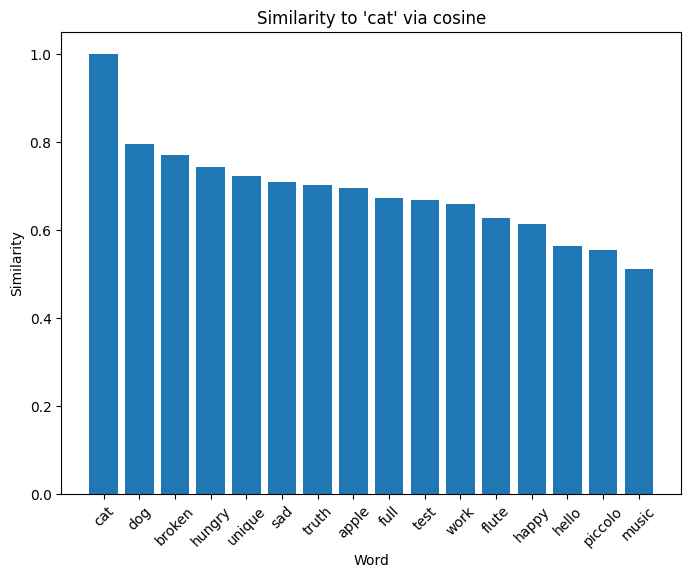

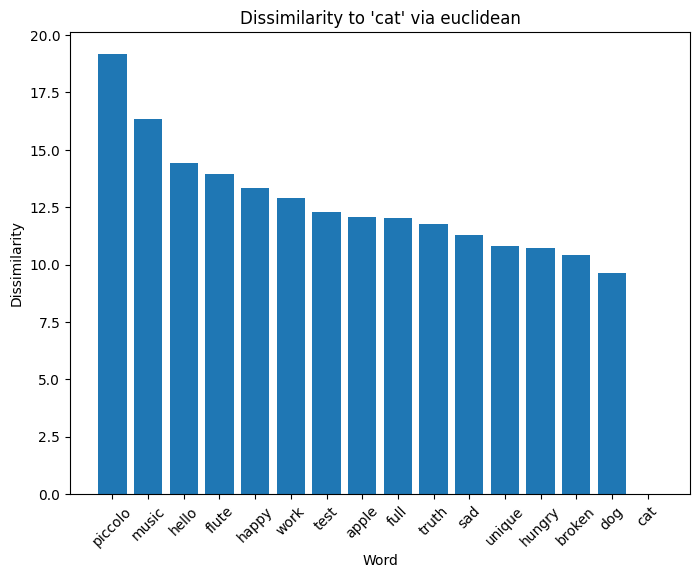

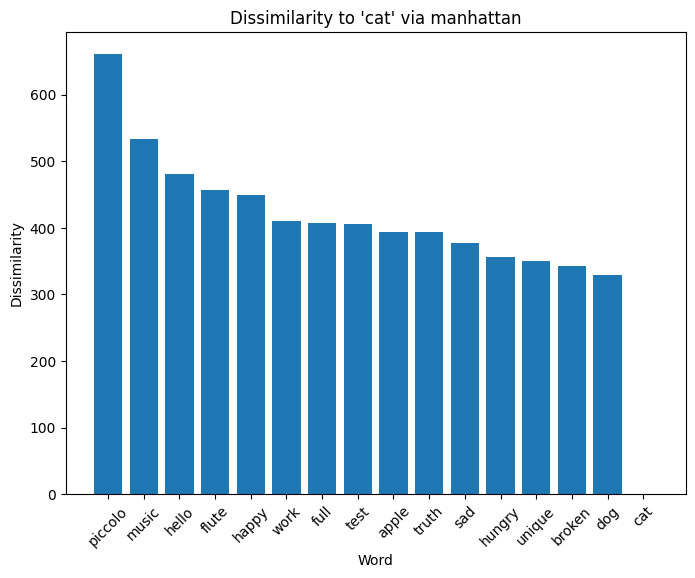

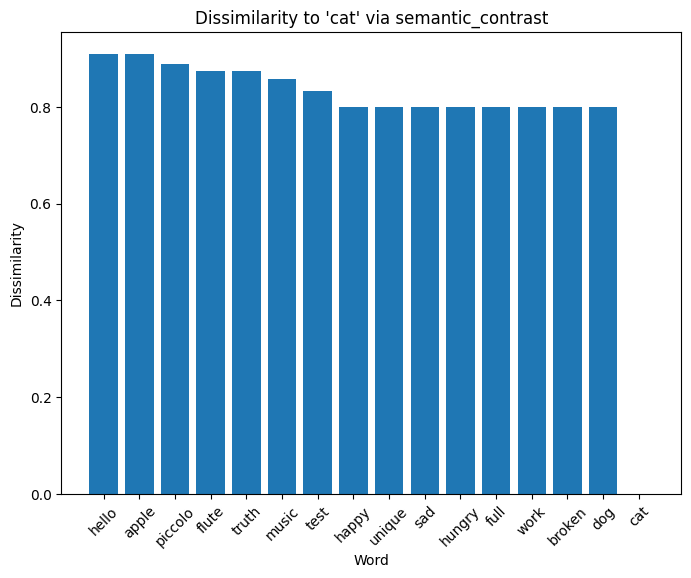

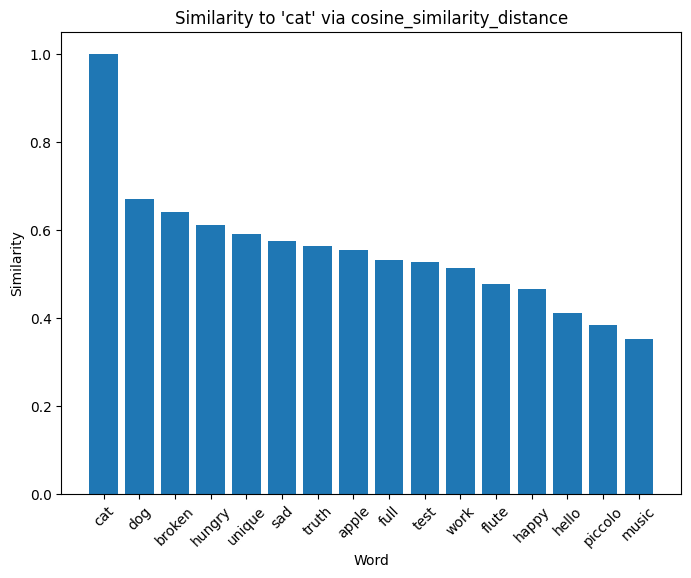

In [13]:
import pandas as pd
target = "cat"
metrics = ["cosine", "euclidean", "manhattan", "semantic_contrast", "cosine_similarity_distance"]
results = []

for metric in metrics:
  for word in words:
    sim = embedding_similarity(word, target, metric)
    results.append({
        "word": word,
        "metric": metric,
        "similarity": sim
    })

df = pd.DataFrame(results)
df["rank"] = df.groupby("metric")["similarity"].rank(ascending=False)

for metric in metrics:
  subset = df[df["metric"] == metric].sort_values("rank")
  plt.figure(figsize=(8,6))
  plt.bar(subset["word"], subset["similarity"])
  plt.xticks(rotation=45)
  metric_type = "Dissimilarity"
  if metric == "cosine" or metric == "cosine_similarity_distance":
    metric_type = "Similarity"
  plt.title(f"{metric_type} to 'cat' via {metric}")
  plt.ylabel(metric_type)
  plt.xlabel("Word")
  plt.show()


For the most part, cat had the least similarity/most dissimilarity with "piccolo" and "music" across all the different metrics, except for semantic contrast. My guess is that "meow" (or something similar) was in a synset for cat, which could correspond to "sing" (or something similar) in the synset for music, which would make them more "similar" by how many synsets apart they are. The word most similar to "cat" (outside of "cat" itself) was "dog" for all the metrics.

Now, we can use a heatmap to compare similarity and dissimilarity across multiple word pairs.

(Note: I interpreted 'word pairs' in this problem to mean comparing the similarity between one word to another word, rather than what I did in part 2, where I interpreted 'two-word embedding' to mean two words compared to another two words. If this is meant to be comparing a pair to another pair, the code to plot similarities/dissimilarities would remain the same, the only change comes in changing the input to the `embedding_similarity` function.)

In [14]:
def similarity_matrix(words, metric):
  matrix = np.zeros((len(words), len(words)))
  for i, word1 in enumerate(words):
    for j, word2 in enumerate(words):
      sim = embedding_similarity(word1, word2, metric)
      matrix[i, j] = sim
  return matrix

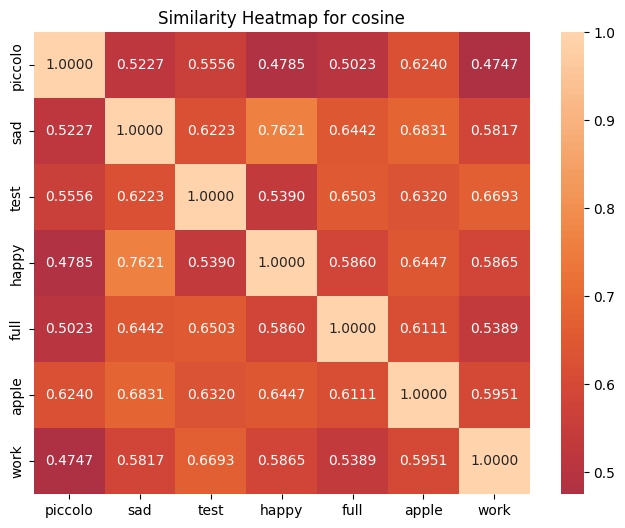

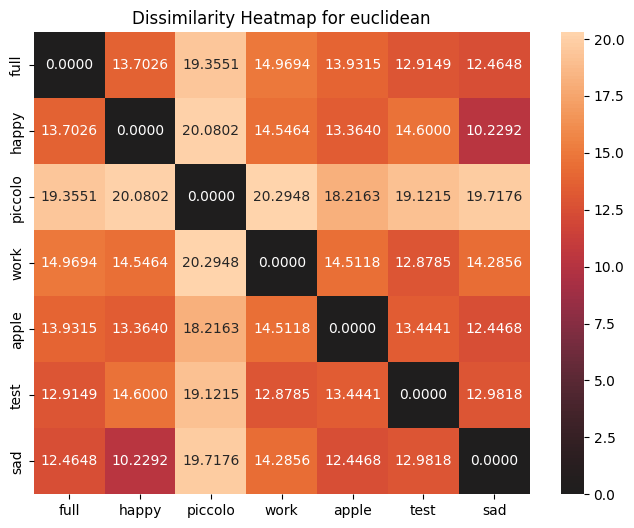

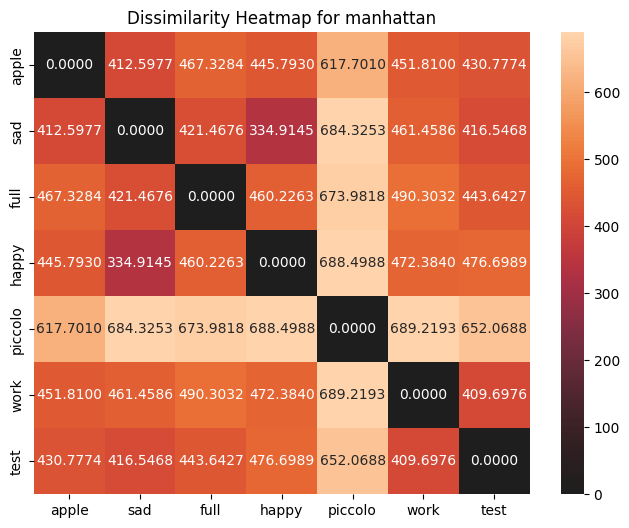

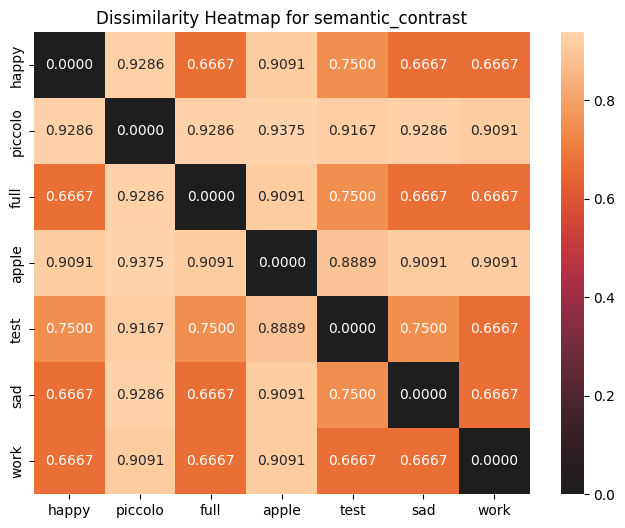

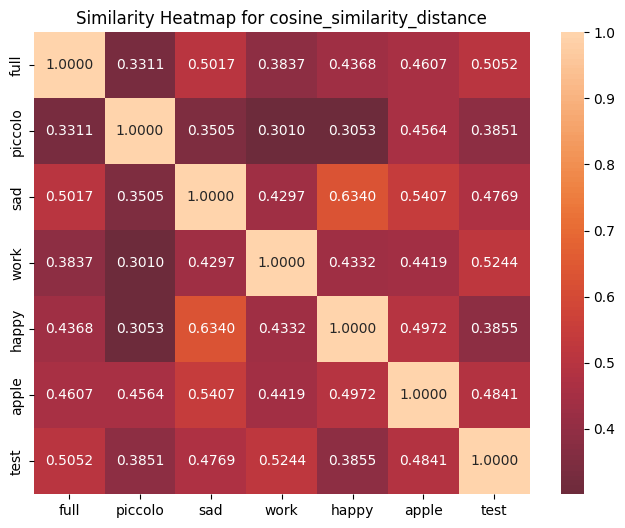

In [15]:
import seaborn as sns

for metric in metrics:
  words = random.sample(words, 7)
  matrix = similarity_matrix(words, metric)
  plt.figure(figsize=(8,6))
  sns.heatmap(
      matrix,
      xticklabels=words,
      yticklabels=words,
      annot=True,
      fmt=".4f",
      center=0
  )
  metric_type = "Dissimilarity"
  if metric == "cosine" or metric == "cosine_similarity_distance":
    metric_type = "Similarity"
  plt.title(f"{metric_type} Heatmap for {metric}")
  plt.show()


I chose to take a sample of my words in order for the heatmap to look nicer. On the similarity heatmaps, higher values (lighter color) mean more similar. On the dissimilarity heatmaps, lower values (dearker color) mean more similar.